In [3]:
%load_ext autoreload
%autoreload 2
from api_keys import OPENAI_API_KEY, GOOGLE_API_KEY
import os 
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

import json

from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

import sciexplorer
from sciexplorer.utils.print_utils import whole_conversation_to_string
from sciexplorer.runs.human_in_the_loop import run_human_in_the_loop
from sciexplorer.utils.model_specifics import get_format_image_function
from sciexplorer.tools.arxiv_tools import arxiv_search
from sciexplorer.tools.coding_tools import execute_code, plot_from_code


/Users/mnaegel/anaconda3/envs/sciexp_v2/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [4]:
model = ChatOpenAI(model="gpt-5")
#model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

# set model type for API-specific printing and image handling
sciexplorer.utils.model_specifics.MODEL_TYPE = "openai"  # or "gemini"

In [5]:
# get previously saved exploration to critique
all_path = './example_results/all_2025-12-08_16-30-51.json'
with open(all_path, 'r') as f:
    previous_exploration = json.load(f)
old_conv_str, old_conv_images = whole_conversation_to_string(previous_exploration['messages'], to_exclude=[('AI', 'REASONING')])

In [6]:
system_prompt = f"""You are a careful scientific research assistant.
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>"""


In [7]:
# Add the previous conversation to the first message
first_message = [{'type': 'text', 'text': f"""Here is a previous conversation between a Scientist and an AI assistant:
<previous_conversation>
{old_conv_str}
</previous_conversation>

Can you please create a simulation of the model the AI proposed and visualize it for the same initial conditions as in the previous conversation?
You do not have access to the previous results in your code.
"""},]
# add previous images to first message
format_image = get_format_image_function()
first_message.extend([format_image(base64_img) for base64_img in old_conv_images])

--binding tools ['arxiv_search', 'execute_code', 'plot_from_code']--
SYSTEM TEXT: You are a careful scientific research assistant.
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>
HUMAN TEXT: Here is a previous conversation between a Scientist and an AI assistant:
<previous_conversation>
SYSTEM TEXT: You are a cautious and curious scientist.
You visualize your data and results before fitting.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>

HUMAN TEXT: 
In this system, you can observe the population dynamics of two species in an experimental biological system.
Figure out the equations of motion governing the dynamics of this system.
Each tool has a maximum runtime of 300 seconds and is automatically terminated if it exceeds this limit.
The results of all tool calls will be stored (using the result_label) and are available later.
Y

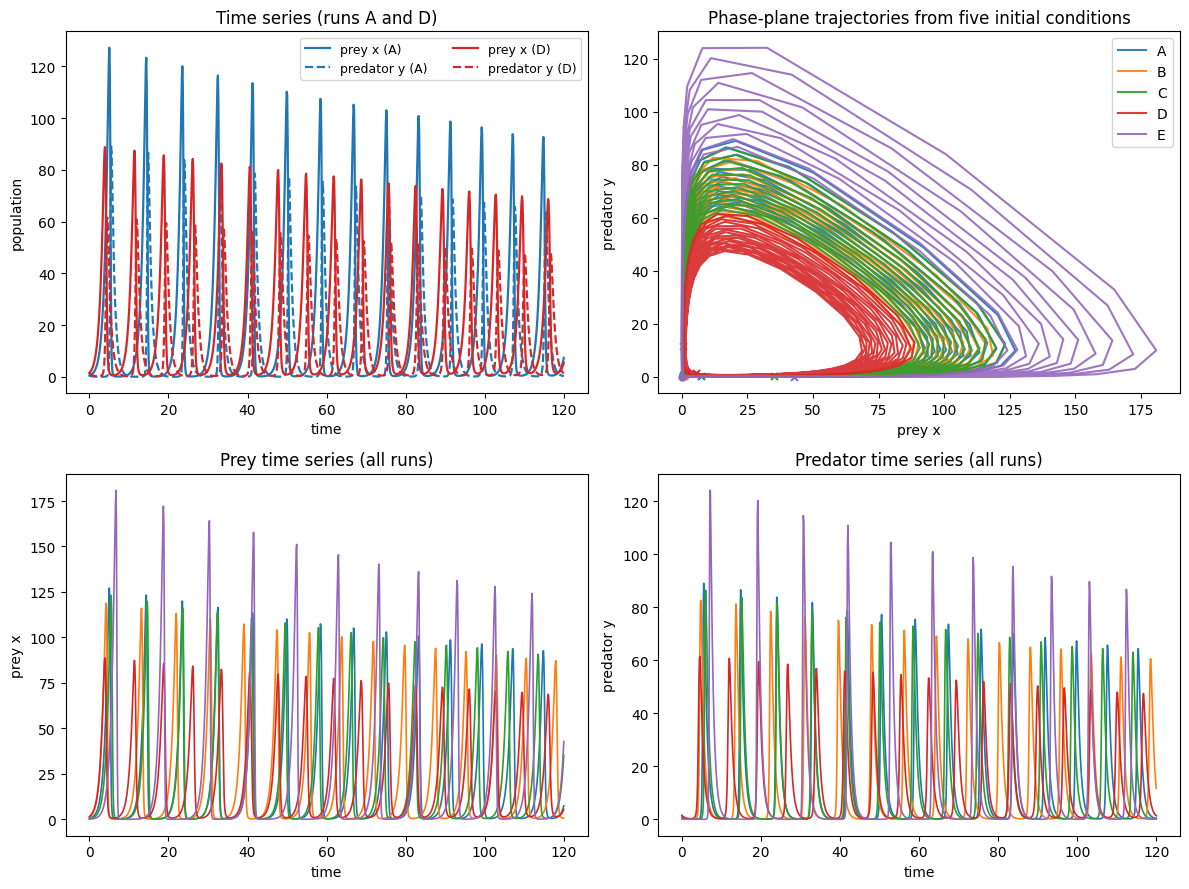

TOOL TEXT: Saved the following result in under <result_key>: <value> 
plots_image: Image data.
TOOL IMAGE: <<Image 0>>
HUMAN TEXT: Do you think the proposed model agress with the treu experiment?
AI REASONING: **Considering model validation**

I'm analyzing the plots, but I notice we only have simulated model data and no true experimental data. Earlier, we noted trajectories from another source, but we can't access them now. We can discuss how well the model agrees with prior observations. From what I remember: the AI validated and indicated a decent fit with the vector field. There were moderate residuals, especially near spikes, so I can generally say it agrees qualitatively but with some caveats regarding numerical errors and discrepancies during predator spikes.
AI REASONING: **Planning further tests**

I’m suggesting some further tests, like simulating with the same initial conditions and overlaying with any available experimental data. It would be helpful to compute trajectory er

In [8]:
final_state = run_human_in_the_loop(
        model = model, # The language model to use
        initial_message = first_message, # The initial message to the agent
        system_message = system_prompt, # The system prompt to guide the agent's behavior
        tools=[arxiv_search, execute_code, plot_from_code], # tools to be used by the agent
        initial_fields=None, # Initial fields available eg. in the execute_code tool
        add_tools_to_fields = False, # Whether to add all tools as callable fields to the _fields dictionary, e.g. to call them from execute_code
        save_path= './example_results', # Path to save the results
        tool_wrapper = None,
        print_intermediate=True, # Whether to print intermediate messages
        print_long_arrays=False, # Whether to print long arrays into the agents context (as opposed to saving them and providing a summary only)
        invoke_kwargs={'reasoning': {'effort': "low",'summary': "auto"}, #kwargs passed when calling the model
                       'verbosity': 'high'},
        add_to_saved_dict = None, # additional information to add to the saved dictionary
        add_to_save_name = 'human_in_the_loop_', # string to add to the save file name
)